# Data Migration: SQL Server to Postgres

In [1]:
import os
import pandas
import pyodbc
import psycopg2
from psycopg2.extras import execute_values
from dotenv import load_dotenv

## 1. Load Credentials

In [2]:
load_dotenv()

True

In [3]:
sql_host = os.getenv("SQL_SERVER_HOST")
sql_db = os.getenv("SQL_SERVER_DB")

In [4]:
print(f"SQL Server Host: {sql_host}")
print(f"SQL Server DB: {sql_db}")

SQL Server Host: BENZO-MATEBOOK\SQLEXPRESS
SQL Server DB: TransactionDB_UAT


In [5]:
pg_host = os.getenv("POSTGRES_HOST")
pg_port = os.getenv("POSTGRES_PORT")
pg_db = os.getenv("POSTGRES_DB")
pg_user = os.getenv("POSTGRES_USER")
pg_password = os.getenv("POSTGRES_PASSWORD")


In [6]:
print(f"PostgreSQL Host: {pg_host}")
print(f"PostgreSQL Port: {pg_port}")
print(f"PostgreSQL DB: {pg_db}")
print(f"PostgreSQL User: {pg_user}")
print(f"PostgreSQL Password: {pg_password}")

PostgreSQL Host: localhost
PostgreSQL Port: 5432
PostgreSQL DB: transaction_uat
PostgreSQL User: postgres
PostgreSQL Password: password


## 2. Connect to SQL Server

In [7]:
print("Connecting to SQL Server...")
print(f"Server: {sql_host}")
print(f"Database: {sql_db}")

Connecting to SQL Server...
Server: BENZO-MATEBOOK\SQLEXPRESS
Database: TransactionDB_UAT


In [8]:
try:
    sql_conn_str = (
        f"DRIVER={{ODBC Driver 17 for SQL Server}};"
        f"SERVER={sql_host};"
        f"DATABASE={sql_db};"
        f"Trusted_Connection=yes;"
    )

    sql_conn = pyodbc.connect(sql_conn_str)
    sql_cursor = sql_conn.cursor()
    print("[SUCCESS] -> Connection to SQL Server completed")

except Exception as e:
    print(f"SQL Server connection failed: {e}")
    print(""" How to troubleshsoot:
          1. Check server name in .env file is correct.
          2. Verify SQL Server is running
          3. Check Windows Authentication is enabled
            ...
    """)

[SUCCESS] -> Connection to SQL Server completed


# 3. Connect to PostgreSQL

In [9]:
print("Connecting to PostegreSQL...")
print(f"Server: {pg_host}")
print(f"Database: {pg_db}")

Connecting to PostegreSQL...
Server: localhost
Database: transaction_uat


In [10]:
try:
    pg_conn = psycopg2.connect(
        host = pg_host,
        port = pg_port,
        database = pg_db,
        user = pg_user,
        password = pg_password
    )

    pg_cursor = pg_conn.cursor()
    pg_cursor.execute("SELECT version();")

    pg_version = pg_cursor.fetchone()

    print("Connected to PostgreSQL database!")
    print(f"PostgreSQL version: {pg_version[:50]}...\n")


except psycopg2.OperationalError as e:
    print(f"PostgreSQL connection failed: {e}")
    print(""" How to troubleshsoot:
          1. Check Postgres is running 
          2. Check username and password are correct
          3. Check if the database exists
            ...
    """)

except Exception as e:
    print(f"Unexpected error: {e}")
    raise

Connected to PostgreSQL database!
PostgreSQL version: ('PostgreSQL 18.3 on x86_64-windows, compiled by msvc-19.44.35223, 64-bit',)...



# 4. Define the table to migrate 

### Migration order

- Categories (No dependencies)
- Suppliers (No dependencies)
- Customer (No dependencies)
- Products (Depends on Categories and  Suppliers) 

In [11]:
tables_to_migrate = ['Categories', 'Suppliers', 'Customers', 'Products']
print(tables_to_migrate)

['Categories', 'Suppliers', 'Customers', 'Products']


In [12]:
print("Table to Migrate:")
for i, table in enumerate(tables_to_migrate, 1):
    print(f"{i}. {table}")

total_no_tbls = len(tables_to_migrate)
print(f"\nTotal Number of tables to migrate: {total_no_tbls}")

Table to Migrate:
1. Categories
2. Suppliers
3. Customers
4. Products

Total Number of tables to migrate: 4


## 5. Run Pre-Migration checks

In [13]:
print("=" * 70)
print(">>> ROW COUNT")
print("=" * 70)

>>> ROW COUNT


In [14]:
baseline_counts = {}

try:
    for table in tables_to_migrate:
        row_count_query = f"SELECT COUNT(*) FROM {table}"
        sql_cursor.execute(row_count_query)
        count = sql_cursor.fetchone()[0]
        
        baseline_counts[table] = count
        print(f"{table:15} {count:>12} rows")

    total_rows = sum(baseline_counts.values())
    print(f"{'-' * 30}")
    print(f"{'TOTAL':15} {total_rows:>12} rows")
    print("\nBaseline Captured Successfully!")


except Exception as e:
    print(f"Error capturing baseline counts: {e}")
    raise

Categories                 8 rows
Suppliers               5000 rows
Customers             900000 rows
Products              150000 rows
------------------------------
TOTAL                1055008 rows

Baseline Captured Successfully!


In [15]:
print("=" * 50)
print(">>>Check 2: NULL COUNTS (CustomerName)")
print("=" * 50)



>>>Check 2: NULL COUNTS (CustomerName)


In [16]:
quality_issues = []

try:
    print("\nCHECK 2: NULL COUNTS (CustomerName)")
    sql_cursor.execute("""SELECT COUNT(*) AS null_count
                          FROM Customers
                          WHERE CustomerName IS NULL""")
    null_names = sql_cursor.fetchone()[0]
    if null_names > 0:
        quality_issues.append(f" -  {null_names:,} customers with NULL names...")
    # print(quality_issues)

    print("\nCHECK 3: INVALID EMAIL FORMATS")
    sql_cursor.execute("""SELECT  COUNT (*) AS invalid_emails_count
                          FROM Customers
                          WHERE Email LIKE '%@invalid%' """)
    invalid_emails = sql_cursor.fetchone()[0]
    if invalid_emails > 0:
        quality_issues.append(f" -  {invalid_emails:,} customers with invalid email formats...")
    # print(quality_issues)

    print("\nCHECK 4: NEGATIVE PRODUCT VALUES")
    sql_cursor.execute("""  SELECT COUNT(*) AS negative_product_prices_counts
                            FROM Products
                            WHERE UnitPrice < 0 """)
    negative_price = sql_cursor.fetchone()[0]
    if negative_price > 0:
        quality_issues.append(f" -  {negative_price:,} prices containing negative prices...")
    # print(quality_issues)

    print("\nCHECK 5: NEGATIVE STOCK QUANTITIES")
    sql_cursor.execute("""  SELECT COUNT(*) AS negative_stock_quantities_count
                            FROM Products
                            WHERE StockQuantity < 0 """)
    negative_stock_quantities = sql_cursor.fetchone()[0]
    if negative_stock_quantities > 0:
        quality_issues.append(f" -  {negative_stock_quantities:,} products with negative stock...")
    # print(quality_issues)

    print("\nCHECK 6: ORPHANED FOREIGN KEYS")
    sql_cursor.execute(""" SELECT COUNT(*) AS orphaned_records
                            FROM Products prod
                            WHERE NOT EXISTS (SELECT 1
                                              FROM Suppliers sup
                                              WHERE sup.SupplierID = prod.SupplierID) """)
    orphaned_fks = sql_cursor.fetchone()[0]
    if orphaned_fks > 0:
        quality_issues.append(f" -  {orphaned_fks:,} products with orphaned foreign keys...")
    # print(quality_issues)

    print("\nCHECK 7: FUTURE DATES CHECK")
    sql_cursor.execute(""" SELECT COUNT(*) AS future_dates_count
                            FROM Customers
                            WHERE CreatedDate > GETDATE() """)
    future_dates = sql_cursor.fetchone()[0]
    if future_dates > 0:
        quality_issues.append(f" -  {future_dates:,} customers with future creation data later than current date...")
    # print(quality_issues)
    
    if quality_issues:
        print("\nData quality issues found (will magrate as-is):")
        for issue in quality_issues:
            print(issue)
    else:
        print("No data quality issues found!")

except Exception as e:
    print(f" [ERROR] ===> Unexpected error occurred: {e}")


CHECK 2: NULL COUNTS (CustomerName)

CHECK 3: INVALID EMAIL FORMATS

CHECK 4: NEGATIVE PRODUCT VALUES

CHECK 5: NEGATIVE STOCK QUANTITIES

CHECK 6: ORPHANED FOREIGN KEYS

CHECK 7: FUTURE DATES CHECK

Data quality issues found (will magrate as-is):
 -  4,514 customers with NULL names...
 -  8,844 customers with invalid email formats...
 -  775 prices containing negative prices...
 -  1,467 products with negative stock...
 -  24,700 products with orphaned foreign keys...


## 6. Get Table Schema 

In [17]:
print("=" * 70)
print("ANALYSE TABLE SCHEMA")
print("=" * 70)

ANALYSE TABLE SCHEMA


In [18]:
import pandas as pd


table_schema = {}

try:
    for table in tables_to_migrate:
        schema_query = f"""SELECT 
                                COLUMN_NAME,
                                DATA_TYPE, 
                                CHARACTER_MAXIMUM_LENGTH, 
                                IS_NULLABLE
                            FROM INFORMATION_SCHEMA.COLUMNS
                            WHERE table_name = '{table}'
                            ORDER BY ORDINAL_POSITION"""
        schema_df = pd.read_sql(schema_query, sql_conn)
        print(f"\n{table}")
        print("-" * 15)
        print(schema_df)
        table_schema[table] = schema_df
        print("\n\n\n")

        
except Exception as e:
    pass


Categories
---------------
    COLUMN_NAME DATA_TYPE  CHARACTER_MAXIMUM_LENGTH IS_NULLABLE
0    CategoryID       int                       NaN          NO
1  CategoryName  nvarchar                      50.0         YES
2   Description  nvarchar                      -1.0         YES






C:\Users\rakom\AppData\Local\Temp\ipykernel_16868\545147933.py:16: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  schema_df = pd.read_sql(schema_query, sql_conn)
C:\Users\rakom\AppData\Local\Temp\ipykernel_16868\545147933.py:16: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  schema_df = pd.read_sql(schema_query, sql_conn)



Suppliers
---------------
    COLUMN_NAME DATA_TYPE  CHARACTER_MAXIMUM_LENGTH IS_NULLABLE
0    SupplierID       int                       NaN          NO
1  SupplierName  nvarchar                     150.0         YES
2   ContactName  nvarchar                     100.0         YES
3       Country  nvarchar                     100.0         YES
4         Phone  nvarchar                      20.0         YES





Customers
---------------
    COLUMN_NAME DATA_TYPE  CHARACTER_MAXIMUM_LENGTH IS_NULLABLE
0    CustomerID       int                       NaN          NO
1  CustomerName  nvarchar                     100.0         YES
2         Email  nvarchar                     100.0         YES
3         Phone  nvarchar                      20.0         YES
4       Country  nvarchar                     100.0         YES
5   CreatedDate  datetime                       NaN         YES
6      IsActive       bit                       NaN         YES





Products
---------------
     COLUMN_NAME

C:\Users\rakom\AppData\Local\Temp\ipykernel_16868\545147933.py:16: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  schema_df = pd.read_sql(schema_query, sql_conn)
C:\Users\rakom\AppData\Local\Temp\ipykernel_16868\545147933.py:16: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  schema_df = pd.read_sql(schema_query, sql_conn)


## 7. Define data type mappings

In [19]:
print("=" * 65)
print("DATA TYPE MAPPING")
print("=" * 65)

DATA TYPE MAPPING


In [20]:
type_mapping = {
    'int': 'INTEGER',
    'bigint': 'BIGINT',
    'smallint': 'SMALLINT',
    'tinyint': 'SMALLINT',
    'bit': 'BOOLEAN',
    'decimal': 'NUMERIC',
    'numeric': 'NUMERIC',
    'money': 'NUMERIC(19,4)',
    'smallmoney': 'NUMERIC(10,4)',
    'float': 'DOUBLE PRECISION',
    'real': 'REAL',
    'datetime': 'TIMESTAMP',
    'datetime2': 'TIMESTAMP',
    'smalldatetime': 'TIMESTAMP',
    'date': 'DATE',
    'time': 'TIME',
    'char': 'CHAR',
    'varchar': 'VARCHAR',
    'nchar': 'CHAR',
    'nvarchar': 'VARCHAR',
    'text': 'TEXT',
    'ntext': 'TEXT',
}

In [21]:
print("SQL Server to PostgreSQL Type Mapping ")
print()

for sql_type, pg_type in type_mapping.items():
    print(f"    {sql_type:15} -> {pg_type}")

SQL Server to PostgreSQL Type Mapping 

    int             -> INTEGER
    bigint          -> BIGINT
    smallint        -> SMALLINT
    tinyint         -> SMALLINT
    bit             -> BOOLEAN
    decimal         -> NUMERIC
    numeric         -> NUMERIC
    money           -> NUMERIC(19,4)
    smallmoney      -> NUMERIC(10,4)
    float           -> DOUBLE PRECISION
    real            -> REAL
    datetime        -> TIMESTAMP
    datetime2       -> TIMESTAMP
    smalldatetime   -> TIMESTAMP
    date            -> DATE
    time            -> TIME
    char            -> CHAR
    varchar         -> VARCHAR
    nchar           -> CHAR
    nvarchar        -> VARCHAR
    text            -> TEXT
    ntext           -> TEXT


## 8. Create Tables in PostgreSQL

In [22]:
print("=" * 70)
print("CREATE TABLE IN POSTGRES")
print("=" * 70)

CREATE TABLE IN POSTGRES


In [23]:
try:
    for table in tables_to_migrate:

        schema = table_schema[table]

        pg_table = table.lower()

        pg_cursor.execute(f"DROP TABLE IF EXISTS {pg_table} CASCADE")

        column_definitions = []

        for idx, row in schema.iterrows():
            col_name = row['COLUMN_NAME'].lower()
            sql_type = row['DATA_TYPE']

            base_type = sql_type.lower()
            pg_type = type_mapping.get(base_type, 'TEXT')

            condition_1 = idx == 0                      # Must be the first column in the table
            condition_2 = col_name.endswith('id')       # Must end with 'id'
            condition_3 = 'int'in sql_type.lower()      # Must be an 'INT' data type

            if condition_1 and condition_2 and condition_3:
                column_definitions.append(f"{col_name} SERIAL PRIMARY KEY")
            else:
                column_definitions.append(f"{col_name} {pg_type}")


        column_string = ",\n        ".join(column_definitions)
        create_query = f"""
            CREATE TABLE {pg_table} (
                {column_string}
            )
        """

        pg_cursor.execute(create_query)
        pg_conn.commit()


    print("\n +" + "=" * 50)
    print(f"[SUCCESS] -> All tables are created successfully in PostgreSQL")
        

except psycopg2.Error as e:
    print(f"Postgre experienced an error while creating tables: {e}")
    pg_conn.rollback()
    raise

except Exception as e:
    print(f"Unexpected error: {e}")
    


 +==================================================
[SUCCESS] -> All tables are created successfully in PostgreSQL


# 9. Test migration with one table

In [24]:
print("=" * 70)
print("TESTING MIGRATION (SINGLE TABLE)")
print("=" * 70)

TESTING MIGRATION (SINGLE TABLE)


In [25]:
test_table = 'Customers'
pg_table = test_table.lower()

In [26]:
try:
    print("1. Read from SQL Server... ")
    extract_query = f"SELECT * FROM {pg_table}"
    test_df = pd.read_sql(extract_query, sql_conn)
    print(f"    Read {len(test_df)} rows ")

    print("2. Transforming data types... ")
    if'IsActive' in test_df.columns:
        test_df['IsActive'] = test_df['IsActive'].astype(bool)
        print("[SUCCESS] --> Converted IsActive: BIT --> BOOLEAN")

    print("3, Preparing the data for loading...")
    data_tuples = [tuple(row) for row in test_df.to_numpy()]

    columns = [col.lower() for col in test_df.columns]
    colum_string = ', '.join(columns)
    placeholders = ', '.join(['%s'] * len(columns))
    insert_query = f"""
        INSERT INTO {pg_table} ({colum_string})
        VALUES %s
    """

    print(f"     Prepared {len(data_tuples):,} rows")

    print("4. Insert data into PostgreSQL... ")
    execute_values(pg_cursor, insert_query, data_tuples, page_size=1000)
    pg_conn.commit()

    print(f"Loaded {len(data_tuples):,} rows")

    print("5. Verifying...")
    pg_cursor.execute(f"SELECT COUNT(*) AS total_rows FROM {pg_table}")
    pg_count = pg_cursor.fetchone()[0]

    sql_count = baseline_counts[test_table]

    if pg_count == sql_count:
        print(f"[SUCCESS] -> Verification passed: {pg_count:,} == {sql_count:,}")
    else:
        print(f"[FAILED] -> Count mismatch: {pg_count:,} != {sql_count:,}")


    print(f"\n {test_table} migration test successfully completed!")


except Exception as e:
    pg_conn.rollback()
    raise

1. Read from SQL Server... 


C:\Users\rakom\AppData\Local\Temp\ipykernel_16868\3036226266.py:4: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  test_df = pd.read_sql(extract_query, sql_conn)


    Read 900000 rows 
2. Transforming data types... 
[SUCCESS] --> Converted IsActive: BIT --> BOOLEAN
3, Preparing the data for loading...
     Prepared 900,000 rows
4. Insert data into PostgreSQL... 
Loaded 900,000 rows
5. Verifying...
[SUCCESS] -> Verification passed: 900,000 == 900,000

 Customers migration test successfully completed!


## 10. Migrate remaining tables

In [27]:
print("=" * 70)
print("MIGRATING REMAINING TABLES")
print("=" * 70)

MIGRATING REMAINING TABLES


In [28]:
remaining_tables = [t for t in tables_to_migrate if t != 'Customers']

for table in remaining_tables:
    pg_table = table.lower()

    print(f"Migrating {table} --> {pg_table}... ")

    try:
        print("1. Reading from SQL Server...")
        extract_query = f"SELECT * FROM {table}"
        sql_df = pd.read_sql(extract_query, sql_conn)
        print(f"     Read {len(sql_df):,} rows\n\n")

        print("2. Preparing data... ")
        data_tuples = [tuple(row) for row in sql_df.to_numpy()]
        columns = [col.lower() for col in sql_df.columns]
        columns_string = ', '.join(columns)
        insert_query = f"""
            INSERT INTO {pg_table} ({columns_string})
            VALUES %s
        """
    
        print(f"     Prepared {len(data_tuples):,} rows\n\n")

        print("3. Processing Bulk load... ")
        execute_values(pg_cursor, insert_query, data_tuples, page_size=1000)
        pg_conn.commit()

        print(f"[SUCCESS] -> Loaded {len(data_tuples):,} rows\n\n")

        print("4. Verifying...")
        pg_cursor.execute(f"SELECT COUNT(*) AS total_rows FROM {pg_table}")
        pg_count = pg_cursor.fetchone()[0]

        sql_count = baseline_counts[table]

        if pg_count == sql_count:
            print(f"[SUCCESS] -> Verification passed: {pg_count:,} == {sql_count:,}")
        else:
            print(f"[FAILED] -> Count mismatch: {pg_count:,} != {sql_count:,}")


        print(f"\n {table} migration successfully completed!")

    except Exception as e:
        print(f"Failed to migrate '{table}': {e}")
        pg_conn.rollback()
        raise


Migrating Categories --> categories... 
1. Reading from SQL Server...
     Read 8 rows


2. Preparing data... 
     Prepared 8 rows


3. Processing Bulk load... 
[SUCCESS] -> Loaded 8 rows


4. Verifying...
[SUCCESS] -> Verification passed: 8 == 8

 Categories migration successfully completed!
Migrating Suppliers --> suppliers... 
1. Reading from SQL Server...


C:\Users\rakom\AppData\Local\Temp\ipykernel_16868\2905463271.py:11: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  sql_df = pd.read_sql(extract_query, sql_conn)
C:\Users\rakom\AppData\Local\Temp\ipykernel_16868\2905463271.py:11: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  sql_df = pd.read_sql(extract_query, sql_conn)


     Read 5,000 rows


2. Preparing data... 
     Prepared 5,000 rows


3. Processing Bulk load... 
[SUCCESS] -> Loaded 5,000 rows


4. Verifying...
[SUCCESS] -> Verification passed: 5,000 == 5,000

 Suppliers migration successfully completed!
Migrating Products --> products... 
1. Reading from SQL Server...


C:\Users\rakom\AppData\Local\Temp\ipykernel_16868\2905463271.py:11: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  sql_df = pd.read_sql(extract_query, sql_conn)


     Read 150,000 rows


2. Preparing data... 
     Prepared 150,000 rows


3. Processing Bulk load... 
[SUCCESS] -> Loaded 150,000 rows


4. Verifying...
[SUCCESS] -> Verification passed: 150,000 == 150,000

 Products migration successfully completed!


## 11. Run post-migration validation

### -> 1. Row count checks 

##### SUCCESS: MATCHES SQL SERVER 

### -> 2. Data type check

##### SUCCESS: MATCHES SQL SERVER

### -> 3. Primary key checks (duplicates)

##### SUCCESS: MATCHES SQL SERVER

### -> 4. Referential integrity checks (duplicates)

##### SUCCESS: MATCHES SQL SERVER

##### XXXX

In [29]:
import matplotlib.pyplot as plt

%matplotlib inline
plt.rcParams['figure.facecolor'] = 'white'

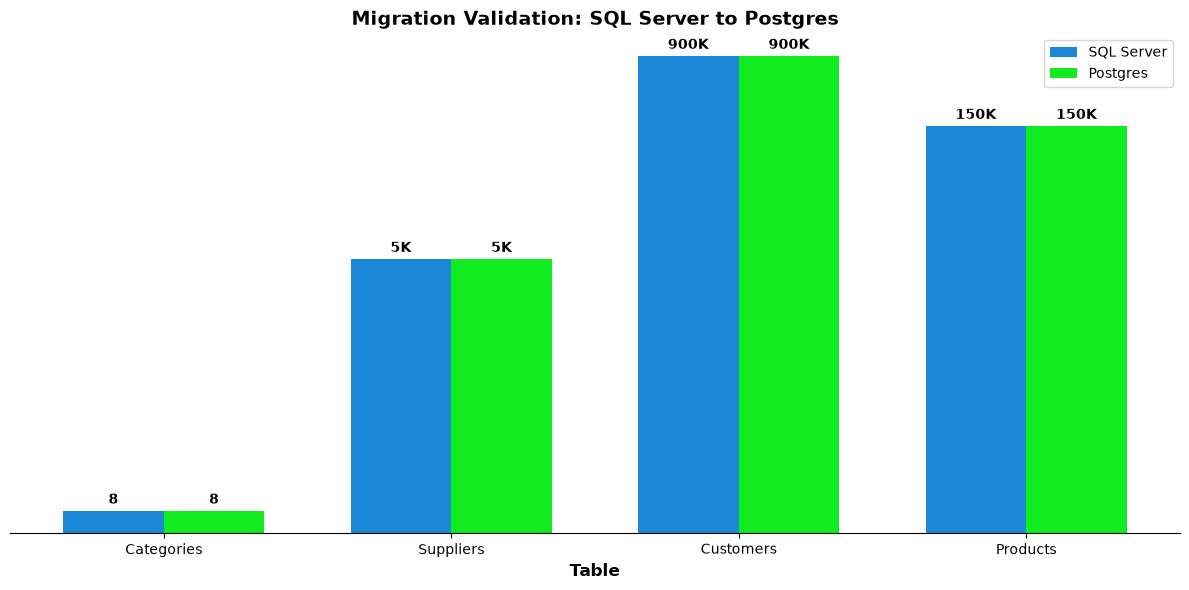

In [46]:
fig, ax = plt.subplots(figsize=(12, 6))

table_names = tables_to_migrate
sql_counts = [baseline_counts[t] for t in tables_to_migrate]

pg_counts = []
for table in tables_to_migrate:
    pg_cursor.execute(f"SELECT COUNT(*) FROM {table.lower()}")
    pg_counts.append(pg_cursor.fetchone()[0])

x = range(len(table_names))
width = 0.35

bars1 = ax.bar([i - width/2 for i in x], 
              sql_counts, 
              width, 
              label='SQL Server', 
              color="#1a88d7")

bars2 = ax.bar([i + width/2 for i in x], 
              pg_counts, 
              width, 
              label='Postgres', 
              color="#10ec1f")

ax.set_xlabel('Table', fontweight='bold', fontsize=12)

ax.set_title('Migration Validation: SQL Server to Postgres', fontweight='bold', fontsize=14)

ax.set_xticks(x)
ax.set_xticklabels(table_names)

ax.get_yaxis().set_visible(False)
ax.spines['left'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)

ax.set_yscale('log')

ax.legend()

for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()

        label = f"{int(height/1000)}K" if height >= 1000 else f'{int(height)}'
        
        ax.text(bar.get_x() + bar.get_width()/2,
                height * 1.1,
                label,
                ha='center', va='bottom', fontsize=10, fontweight='bold')
        
plt.tight_layout()
plt.show()
                